# Analyse d'Échec

In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator
from src.models.fourier import FourierRegressor
from src.models.xgboost_regressor import XGBoostRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

perfect_evaluator = TimeSeriesEvaluator(df, "perfect")
realistic_evaluator = TimeSeriesEvaluator(df, "realistic")

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

pdf_train, pdf_val, pdf_test = perfect_evaluator.split_data(val_start, test_start, load_existing_splits=True)
rdf_train, rdf_val, rdf_test = realistic_evaluator.split_data(val_start, test_start, load_existing_splits=True)

In [2]:
_, perfect_result = perfect_evaluator.grid_search_rolling_validation(XGBoostRegressor, [{}])
_ , realistic_result = realistic_evaluator.grid_search_rolling_validation(XGBoostRegressor, [{}])

perfect_xgb = perfect_result['model']
perfect_evaluator.rolling_test(perfect_xgb)
realistic_xgb = realistic_result['model']
realistic_evaluator.rolling_test(realistic_xgb);

Grid Search de XGBoostRegressorCustom :

Combination 1/1 : {}
Évaluation de XGBoostRegressorCustom | 8784 lignes | réentraînement/6ME | 3 itérations

Nombre d'arbres réellement retenus (best_iteration) : 2983 / 3000
Meilleure MAE validation : 871.25
Progression: 2024-01-01 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 2996 / 3000
Meilleure MAE validation : 1289.09
Progression: 2024-01-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 552 / 3000
Meilleure MAE validation : 475.81
Progression: 2024-07-31 00:00...
Train : MAE = 548.95 MW |RMSE = 816.36 MW |MAPE = 1.04%


Validation : MAE = 889.25 MW |RMSE = 1236.53 MW |MAPE = 1.76%

Best MAE sur Validation : 889.25 MW
Best Params : {}

Grid Search de XGBoostRegressorCustom :

Combination 1/1 : {}
Évaluation de XGBoostRegressorCustom | 8784 lignes | réentraînement/6ME | 3 itérations

Nombre d'arbres réellement retenus (best_iteration) : 412 / 3000
Meilleure MAE validation : 1802.21
Progression: 2024-01-01 00

--- Contexte Calendaire des jours problématiques ---


,saison_meteorologique,weekend,ferie,vacances,confinement_numero
date,,,,,
2025-01-05,Hiver,True,False,3,0.0
2025-01-27,Hiver,False,False,0,0.0
2026-01-05,Hiver,False,False,0,0.0


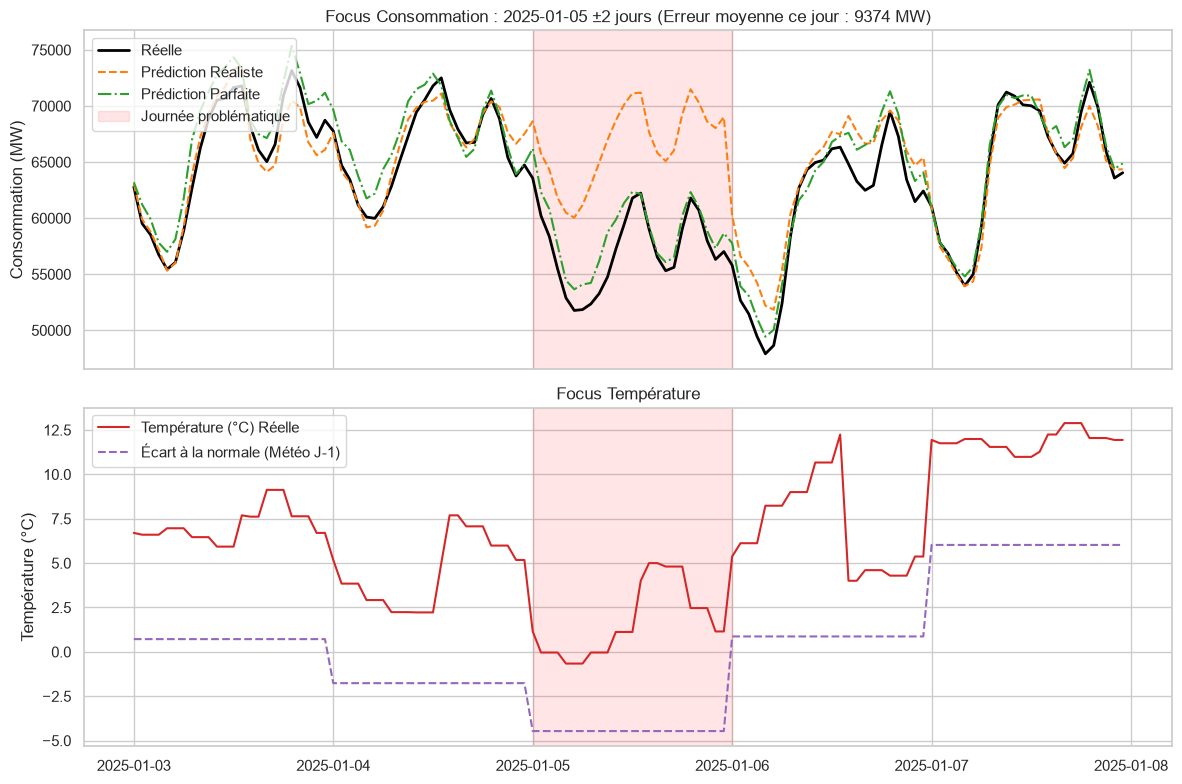

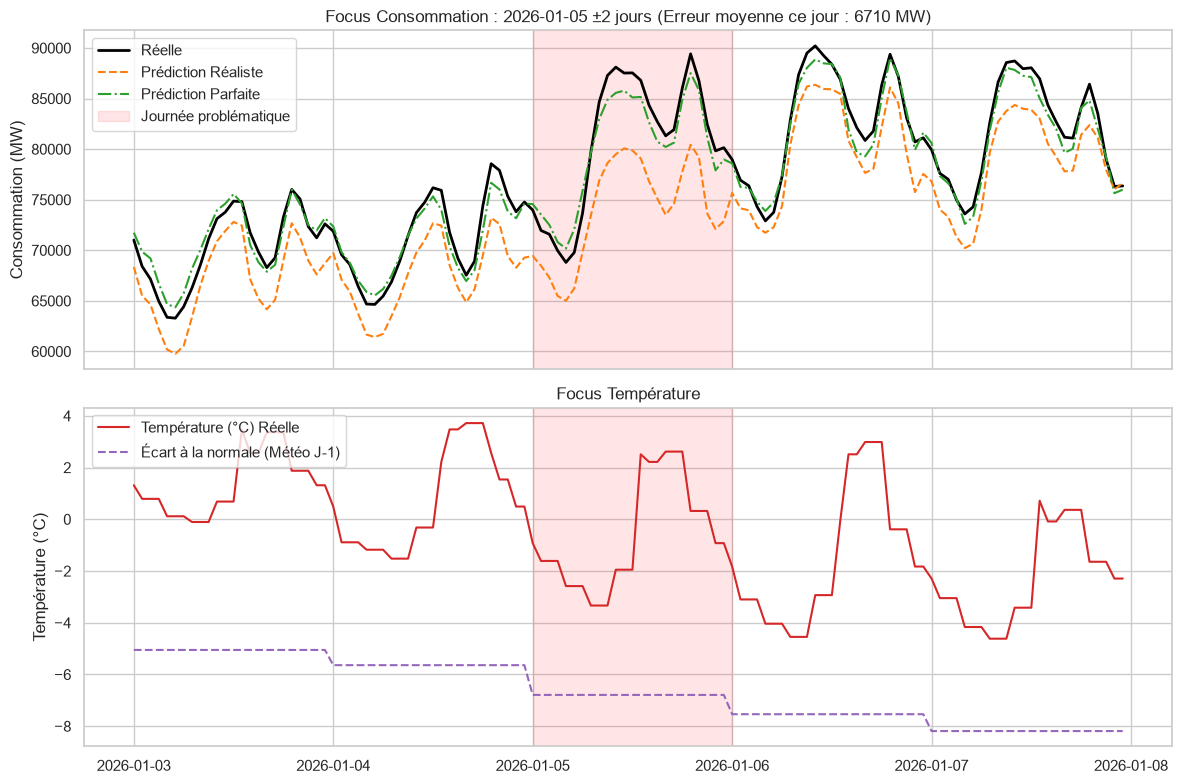

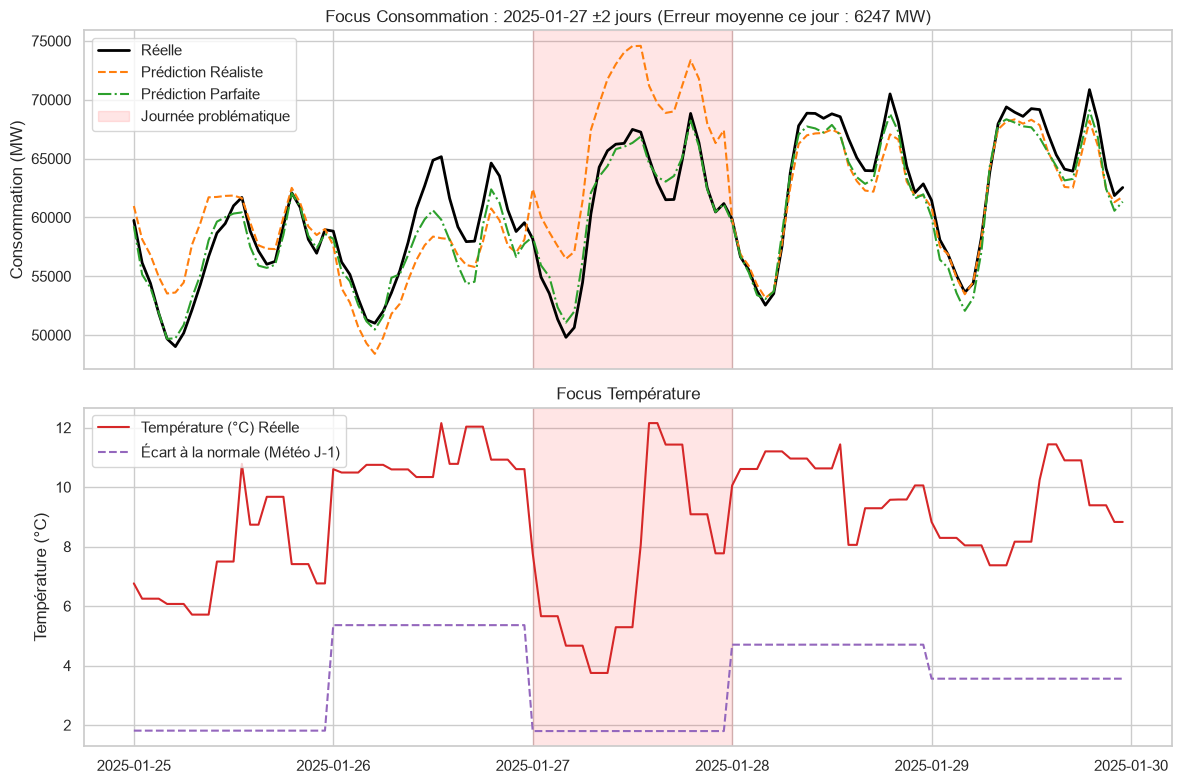

In [ ]:
# Récupération des prédictions
key = list(realistic_evaluator.models.keys())[0]
real_preds = realistic_evaluator.models[key]['test_preds']
perf_preds = perfect_evaluator.models[key]['test_preds']

df_plot = rdf_test.copy()
df_plot['real_pred'] = real_preds
df_plot['perf_pred'] = perf_preds
df_plot['true'] = df_plot['cible_consommation_mw']
df_plot['real_err'] = (df_plot['true'] - df_plot['real_pred']).abs()
df_plot['date'] = df_plot['cible_timestamp_paris'].dt.date

daily_err = df_plot.groupby('date')['real_err'].mean()
worst_days = daily_err.sort_values(ascending=False).head(3).index.tolist()

# 1. Tableau récapitulatif du contexte calendaire pour les jours problématiques
df_table = df_plot[df_plot['date'].isin(worst_days)].groupby('date').first()[
    ['saison_meteorologique', 'weekend', 'ferie', 'vacances', 'confinement_numero']
]
display(df_table)

# 2. Historique complet pour avoir le Day-2 même si c'est au début du test set
full_df = pd.concat([rdf_train, rdf_val, rdf_test]).copy()
full_df['date'] = full_df['cible_timestamp_paris'].dt.date

# 3. Tracé détaillé sur 5 jours pour chaque journée problématique
for day in worst_days:
    start_day = day - pd.Timedelta(days=2)
    end_day = day + pd.Timedelta(days=2)

    window_df = full_df[(full_df['date'] >= start_day) & (full_df['date'] <= end_day)]
    window_preds = df_plot[(df_plot['date'] >= start_day) & (df_plot['date'] <= end_day)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot 1: Consommation
    axes[0].plot(window_df['cible_timestamp_paris'], window_df['cible_consommation_mw'], label='Réelle', color='black', linewidth=2)
    if not window_preds.empty:
        axes[0].plot(window_preds['cible_timestamp_paris'], window_preds['real_pred'], label='Prédiction Réaliste', linestyle='--', color='tab:orange')
        axes[0].plot(window_preds['cible_timestamp_paris'], window_preds['perf_pred'], label='Prédiction Parfaite', linestyle='-.', color='tab:green')

    # Highlight the bad day
    day_start_dt = pd.to_datetime(day).tz_localize('Europe/Paris')
    day_end_dt = day_start_dt + pd.Timedelta(days=1)
    axes[0].axvspan(day_start_dt, day_end_dt, color='red', alpha=0.1, label='Journée problématique')

    mae_real = df_plot[df_plot['date'] == day]['real_err'].mean()
    axes[0].set_title(f"Focus Consommation : {day} ±2 jours (Erreur moyenne ce jour : {mae_real:.0f} MW)")
    axes[0].set_ylabel('Consommation (MW)')
    axes[0].legend(loc='upper left')

    # Plot 2: Température
    axes[1].plot(window_df['cible_timestamp_paris'], window_df['temperature_c_pondere_pop_meme_heure_derniere_connue'], label='Température (°C) Réelle', color='tab:red')
    axes[1].plot(window_df['cible_timestamp_paris'], window_df['temperature_c_pondere_pop_ecart_normale_derniere_connue'], label='Écart à la normale (Météo J-1)', color='tab:purple', linestyle='--')

    axes[1].axvspan(day_start_dt, day_end_dt, color='red', alpha=0.1)

    axes[1].set_title("Focus Température")
    axes[1].set_ylabel('Température (°C)')
    axes[1].legend(loc='upper left')

    plt.tight_layout()
    plt.show()
